In [1]:
import os
import sys
import numpy as np
from PIL import Image
from IPython.display import HTML

sys.path.append(os.path.abspath("."))

from fashion_detector.config import Config
from fashion_detector.models.sam import SamDetector
from fashion_detector.models.vision_llm import VisionLlmDetector
from fashion_detector.utils import (
    load_image,
    generate_interactive_html,
    visualize_detections,
    display_img,
    user_categories,
    mapped_user_categories,
    execute_detection,
    clean_categories,
    display_imageGrid
)

# Load configuration
config = Config("config/config.yaml")
llm_detector = VisionLlmDetector(config)


# Initialize SAM Detector
# detector = SamDetector(config)
# detector.load_model()
from fashion_detector.models.sam3_segmenter import SamSegmenter
# config.models['sam']['name'] = "facebook/sam2.1-hiera-small"
config.models['sam']['name'] = "facebook/sam3"
sam_segmenter = SamSegmenter(config)
sam_segmenter.load_model()

[2026-07-23 22:31:03] [INFO] [fashion_detector:config.py:169] - Configuration loaded from config/config.yaml. Device set to: mps
[2026-07-23 22:31:03] [INFO] [fashion_detector:sam3_segmenter.py:695] - Factory routing execution architecture -> Sam3Detector Subclass
[2026-07-23 22:31:03] [INFO] [fashion_detector:sam3_segmenter.py:178] - Loading SAM 3 model: facebook/sam3 on device: mps
[2026-07-23 22:31:07] [INFO] [fashion_detector:sam3_segmenter.py:188] - SAM 3 processor loaded successfully.


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

[2026-07-23 22:31:12] [INFO] [fashion_detector:sam3_segmenter.py:201] - SAM 3 model loaded successfully.
[2026-07-23 22:31:12] [INFO] [fashion_detector:sam3_segmenter.py:211] - SAM 3 model is now ready for inference.


In [2]:
import json
with open("detections_v2.json", "r") as f:
    detections = json.load(f)

[2026-07-23 22:37:20] [INFO] [fashion_detector:utils.py:120] - Loading image from local path: /Users/sunnyraj/Downloads/images-3.jpeg
[2026-07-23 22:37:20] [INFO] [fashion_detector:utils.py:120] - Loading image from local path: /Users/sunnyraj/Downloads/images-3.jpeg
[2026-07-23 22:37:20] [INFO] [fashion_detector:logging.py:98] - Starting: Vision LLM Inference
[2026-07-23 22:37:20] [INFO] [fashion_detector:vision_llm.py:269] - Querying Vision LLM openai/google/gemma-4-e4b via LiteLLM...
[2026-07-23 22:40:31] [INFO] [fashion_detector:vision_llm.py:336] - Vision LLM detected 5 items.
[2026-07-23 22:40:31] [INFO] [fashion_detector:logging.py:103] - Completed: Vision LLM Inference in 191.3090 seconds
[2026-07-23 22:40:31] [INFO] [fashion_detector:utils.py:91] - Hybrid pipeline detected 5 fashion items:
[2026-07-23 22:40:31] [INFO] [fashion_detector:utils.py:93] - - Tops (refined from None): score=1.00
[2026-07-23 22:40:31] [INFO] [fashion_detector:utils.py:93] - - Pants (refined from None)


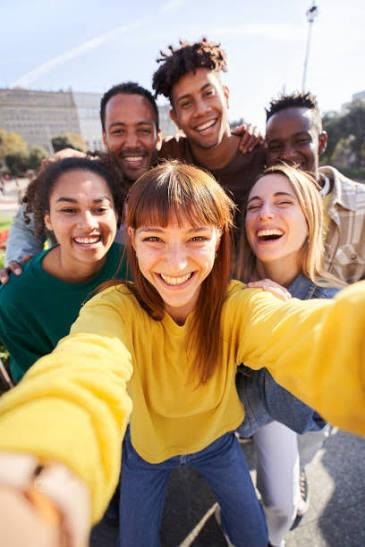

In [14]:
image_path = detections[0]['image_path']
image = load_image(image_path)
w, h = image.size
image_detections = execute_detection(image_path, detector=llm_detector, visualize=True)

### For Sam2

In [ ]:
# image = load_image(detections[0]['image_path'])
# # boxes = [det['box'] for det in detections[0]['detections']]
# box_inputs = detections[0]['detections']

# segmented_image = sam_segmenter.segment_with_boxes(image, box_inputs)
# # Pass your image and target coordinates to get list of separate images
# cutout_images = sam_segmenter.extract_segmented_parts(image, box_inputs)

[2026-07-23 11:22:52] [INFO] [fashion_detector:utils.py:119] - Loading image from local path: /Users/sunnyraj/Downloads/images-3.jpeg
[2026-07-23 11:22:52] [INFO] [fashion_detector:logging.py:98] - Starting: sam2_box_segmentation
[2026-07-23 11:22:52] [INFO] [fashion_detector:sam3_segmenter.py:29] - Loading SAM 2 model: facebook/sam2.1-hiera-small on device: mps


Loading weights:   0%|          | 0/357 [00:00<?, ?it/s]

[2026-07-23 11:22:58] [INFO] [fashion_detector:sam3_segmenter.py:40] - SAM 2 model loaded successfully.
[2026-07-23 11:22:59] [INFO] [fashion_detector:logging.py:103] - Completed: sam2_box_segmentation in 7.0673 seconds
[2026-07-23 11:22:59] [INFO] [fashion_detector:logging.py:98] - Starting: sam2_box_extraction
[2026-07-23 11:22:59] [INFO] [fashion_detector:logging.py:103] - Completed: sam2_box_extraction in 0.3597 seconds


In [9]:
# for det in detections:
#     print(f"Processing image: {det['image_path']}")
#     image = load_image(det['image_path'])
#     box_inputs = det['detections']
#     # segmented_image = sam_segmenter.segment_with_boxes(image, box_inputs)
#     cutout_images = sam_segmenter.extract_segmented_parts(image, box_inputs)
#     display_imageGrid(cutout_images, imgs_per_row=5)

### For Sam3

[2026-07-23 22:41:10] [INFO] [fashion_detector:utils.py:120] - Loading image from local path: /Users/sunnyraj/Downloads/images-3.jpeg


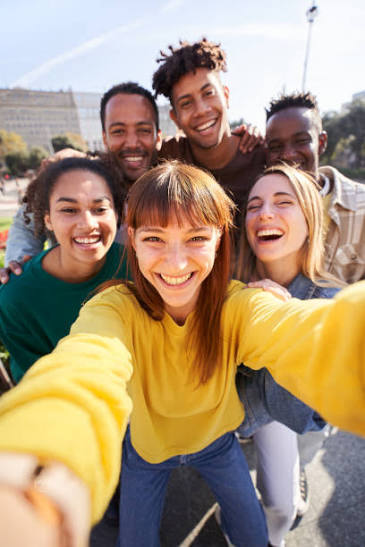

In [15]:
image_path = "/Users/sunnyraj/Downloads/images-3.jpeg"
# image_path = "/Users/sunnyraj/Downloads/images-2.jpeg"
# image_path = "/Users/sunnyraj/Downloads/images.jpeg"
image = load_image(image_input=image_path)
image

In [16]:
image_detections

[Detection(box=[0.0, 268.03, 302.95, 547.0], label='tops', score=1.0, mask=None, metadata={'raw_llm_box': [490.0, 0.0, 1000.0, 830.0]}),
 Detection(box=[87.6, 410.25, 266.45, 547.0], label='pants', score=0.95, mask=None, metadata={'raw_llm_box': [750.0, 240.0, 1000.0, 730.0]}),
 Detection(box=[0.0, 229.73999999999998, 127.74999999999999, 399.31], label='tops', score=0.9, mask=None, metadata={'raw_llm_box': [420.0, 0.0, 730.0, 350.0]}),
 Detection(box=[226.3, 164.1, 343.09999999999997, 388.37], label='tops', score=0.85, mask=None, metadata={'raw_llm_box': [300.0, 620.0, 710.0, 940.0]}),
 Detection(box=[288.35, 153.16000000000003, 365.0, 295.38], label='shirts', score=0.75, mask=None, metadata={'raw_llm_box': [280.0, 790.0, 540.0, 1000.0]})]

[2026-07-23 22:47:31] [INFO] [fashion_detector:logging.py:98] - Starting: sam3_box_extraction
[2026-07-23 22:47:57] [INFO] [fashion_detector:logging.py:103] - Completed: sam3_box_extraction in 25.8558 seconds


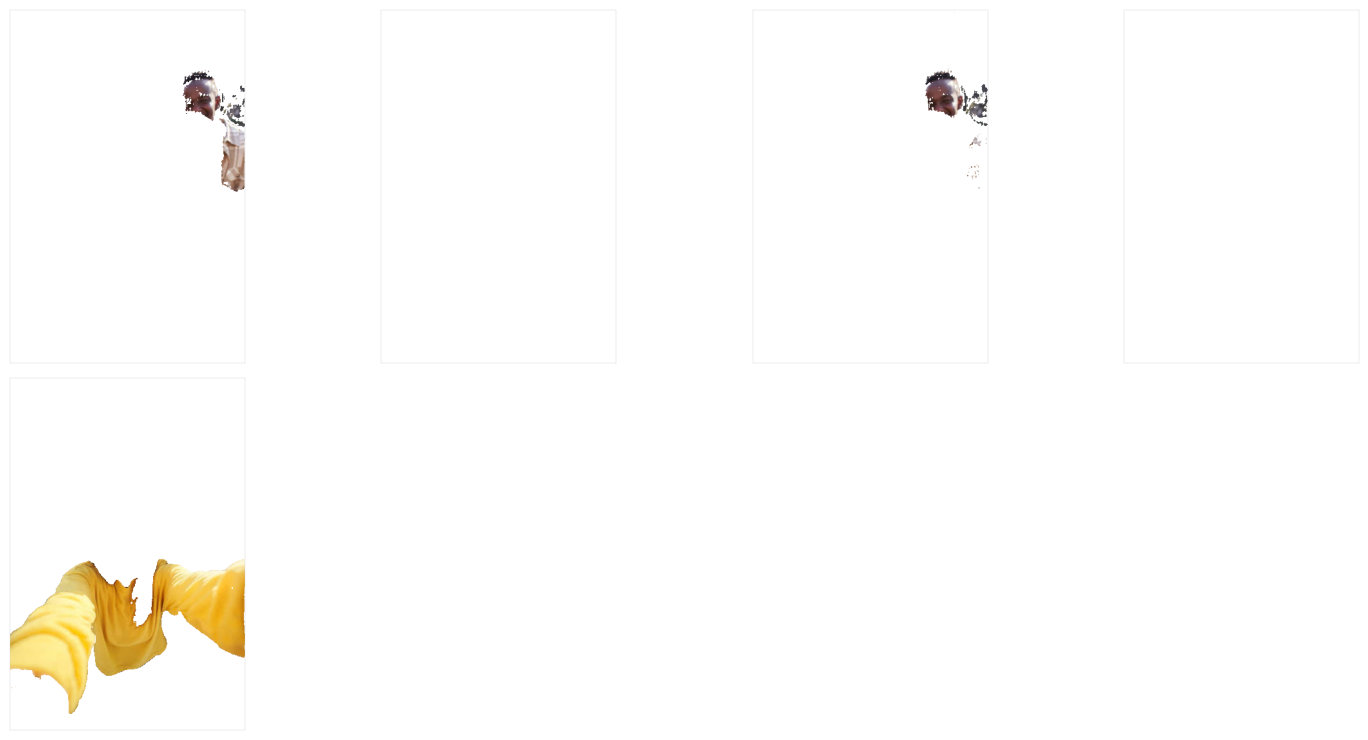

In [20]:
segmented_parts = sam_segmenter.extract_segmented_parts(
    image,
    box_inputs=llm_detector._to_dict(image_detections),
    labels=[a.label for a in image_detections]
    )
display_imageGrid(segmented_parts, border_width=0.25, imgs_per_row=4)

[2026-07-23 22:50:14] [INFO] [fashion_detector:logging.py:98] - Starting: sam3_concept_segmentation
[2026-07-23 22:50:18] [INFO] [fashion_detector:sam3_segmenter.py:548] - For SAM 3 zero-shot promptable concept queries on this image, the confidence scores were:
[2026-07-23 22:50:18] [INFO] [fashion_detector:sam3_segmenter.py:558] -   • No candidate concept masks detected above score 0.05.
[2026-07-23 22:50:18] [INFO] [fashion_detector:logging.py:103] - Completed: sam3_concept_segmentation in 3.6470 seconds


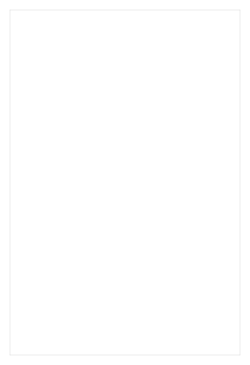

In [26]:
segmented_parts = sam_segmenter.segment_with_concepts(image,['bird'])
display_imageGrid([segmented_parts], border_width=0.25, imgs_per_row=4)

[2026-07-23 22:36:42] [INFO] [fashion_detector:logging.py:98] - Starting: sam3_concept_extraction
[2026-07-23 22:36:46] [INFO] [fashion_detector:sam3_segmenter.py:651] - For SAM 3 zero-shot promptable concept queries on this image, the confidence scores were:
[2026-07-23 22:36:46] [INFO] [fashion_detector:sam3_segmenter.py:659] -   • tops: 0.0701
[2026-07-23 22:36:46] [INFO] [fashion_detector:sam3_segmenter.py:659] -   • jeans: 0.0966
[2026-07-23 22:36:46] [INFO] [fashion_detector:logging.py:103] - Completed: sam3_concept_extraction in 3.6971 seconds


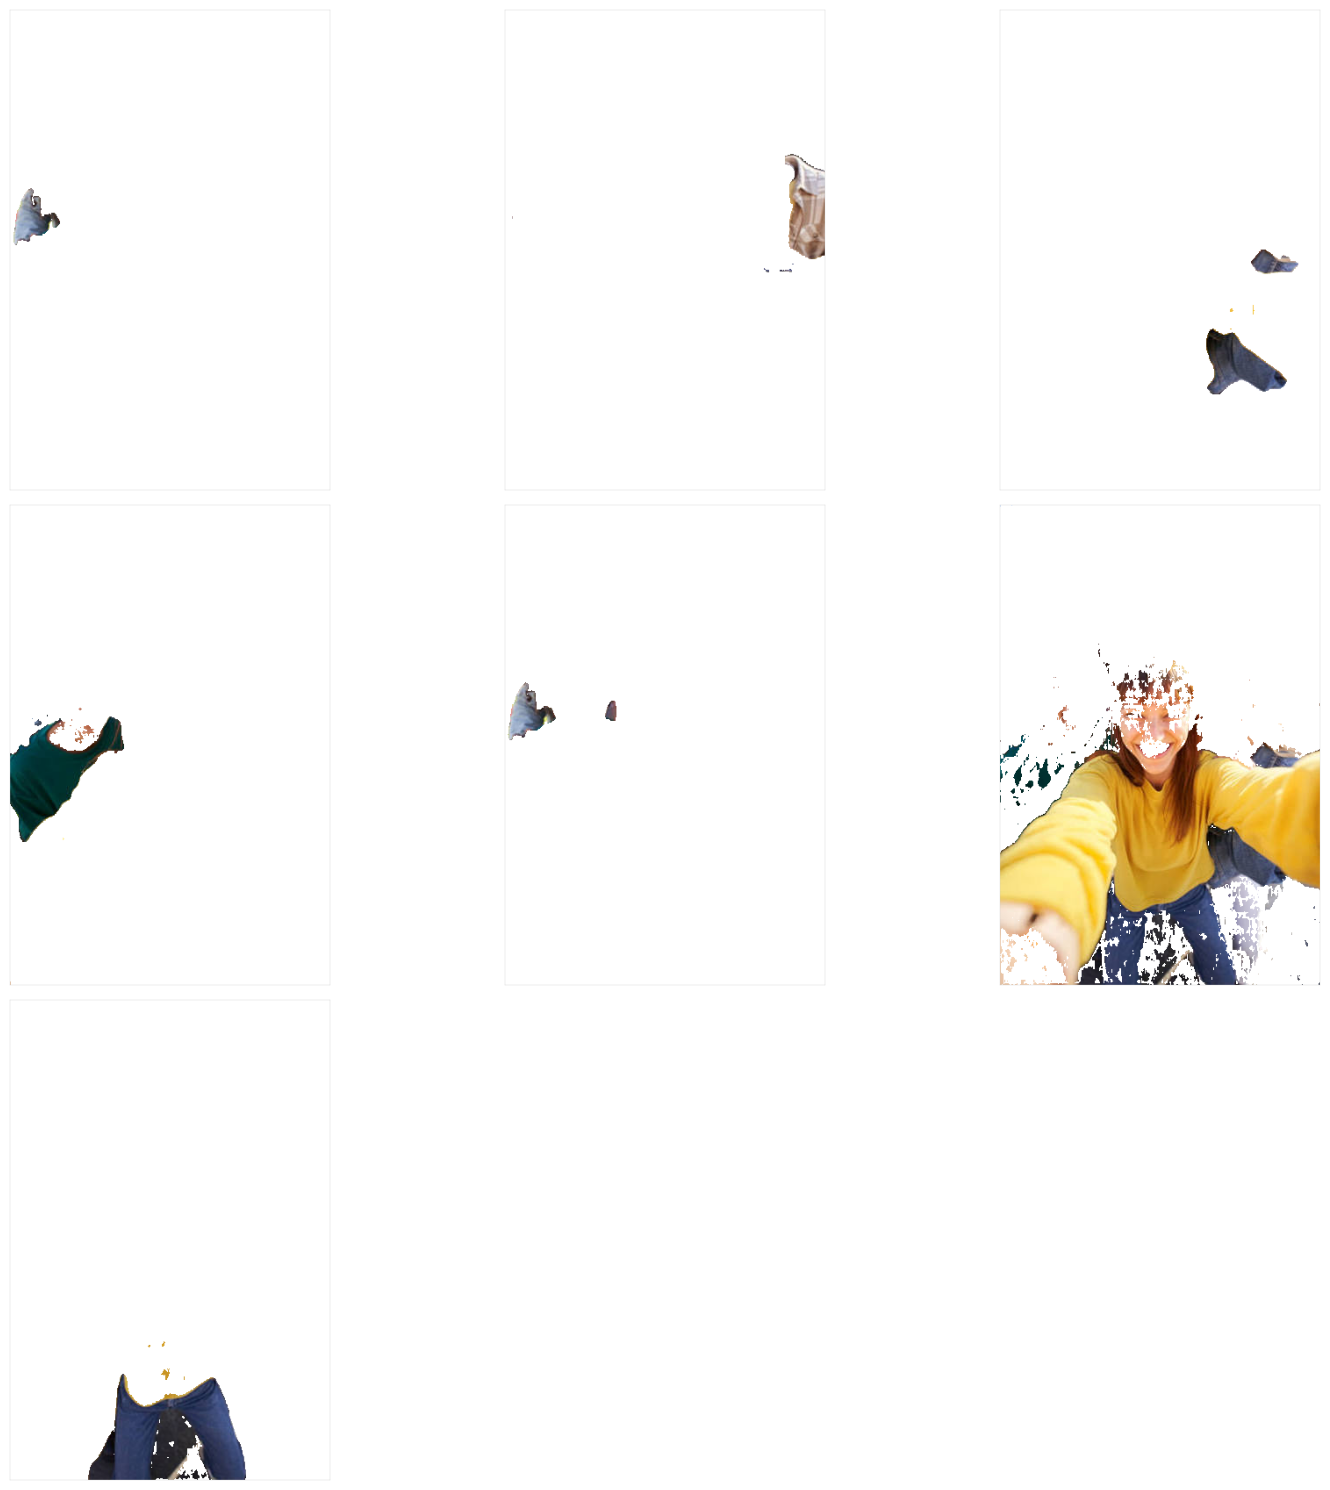

In [12]:
individual_cutouts = sam_segmenter.extract_concept_parts(image, ['tops', 'jeans'])
display_imageGrid(individual_cutouts, border_width=0.25)

[2026-07-23 22:04:36] [INFO] [fashion_detector:utils.py:119] - Loading image from local path: /Users/sunnyraj/Downloads/images-3.jpeg


total 4 lables : ['shirt', 'top', 'jeans', 'sweater']
[2026-07-23 22:04:36] [INFO] [fashion_detector:logging.py:98] - Starting: sam3_concept_extraction
[2026-07-23 22:04:54] [INFO] [fashion_detector:sam3_segmenter.py:574] - For SAM 3 zero-shot promptable concept queries on this image, the confidence scores were:
[2026-07-23 22:04:55] [INFO] [fashion_detector:sam3_segmenter.py:582] -   • shirt: 0.0643
[2026-07-23 22:04:55] [INFO] [fashion_detector:sam3_segmenter.py:582] -   • top: 0.1021
[2026-07-23 22:04:55] [INFO] [fashion_detector:sam3_segmenter.py:582] -   • jeans: 0.0678
[2026-07-23 22:04:55] [INFO] [fashion_detector:sam3_segmenter.py:582] -   • sweater: 0.0585
[2026-07-23 22:04:55] [INFO] [fashion_detector:logging.py:103] - Completed: sam3_concept_extraction in 18.3167 seconds
length : 9


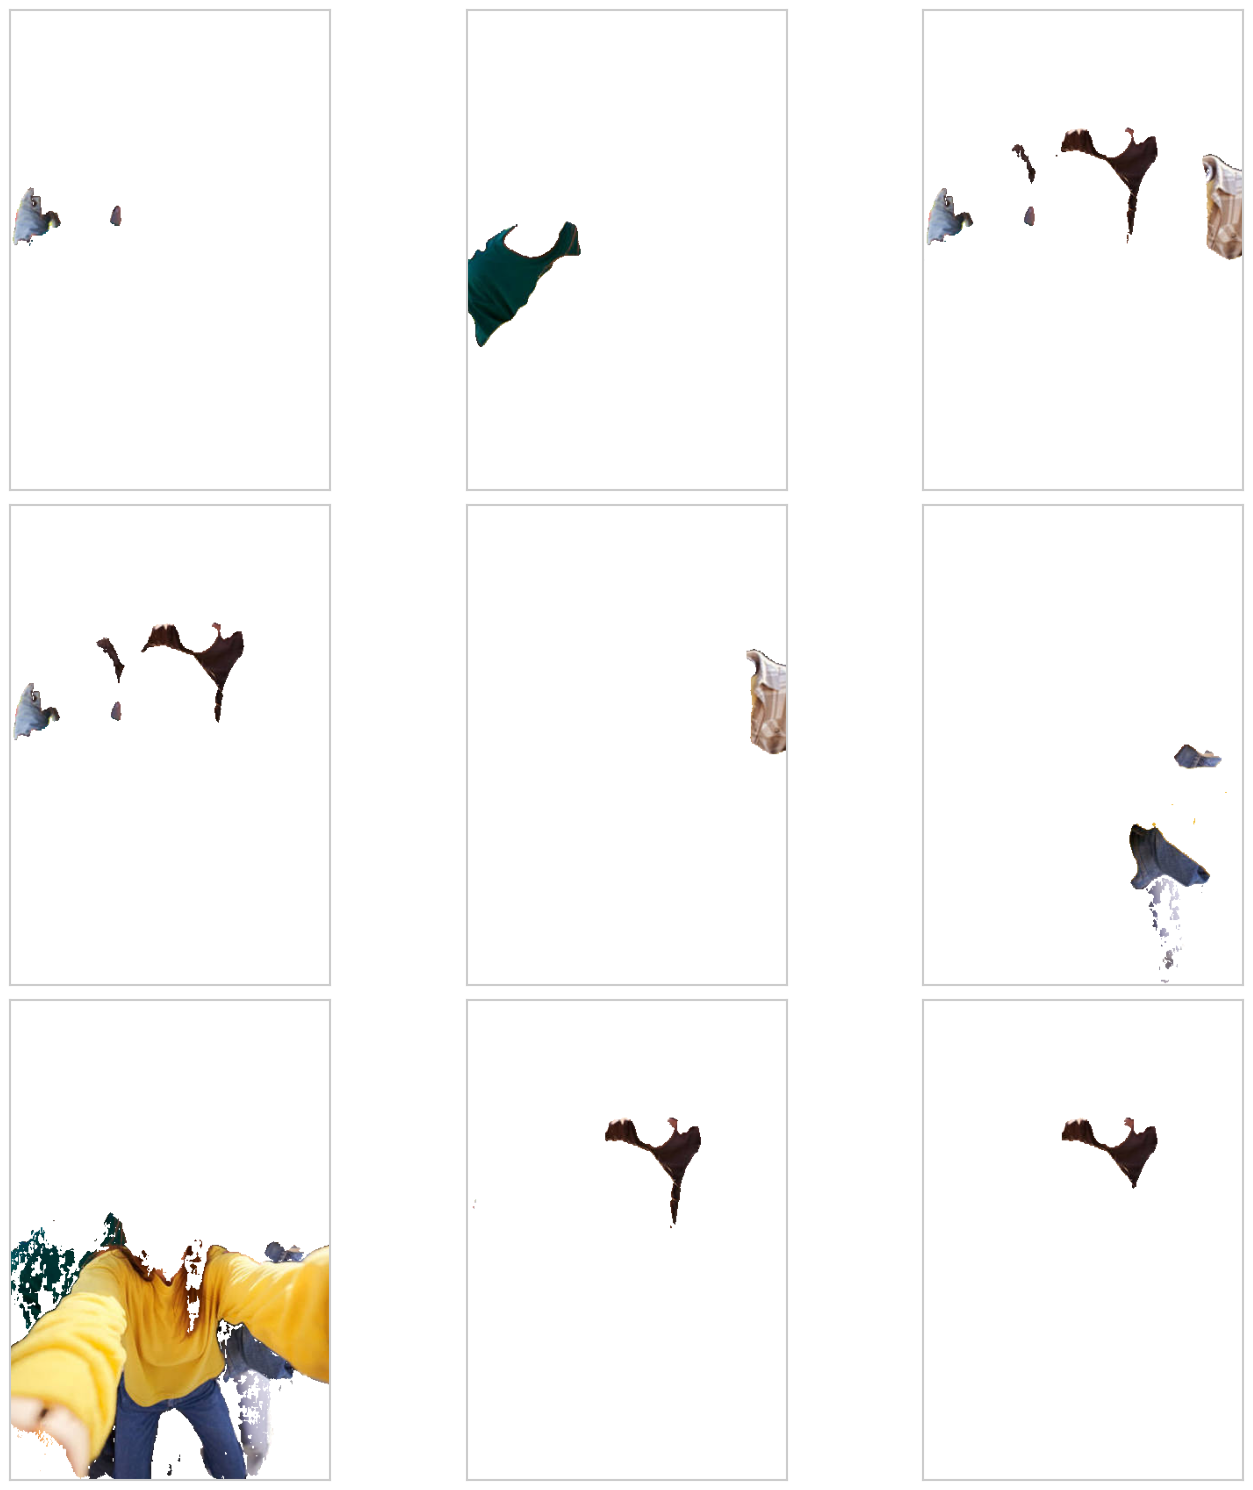

In [4]:
image = load_image(detections[0]['image_path'])
box_inputs = detections[0]['detections']
lables = list(set([a['label'] for a in detections[0]['detections']]))
print(f"total {len(lables)} lables : {lables}")
individual_cutouts = sam_segmenter.extract_concept_parts(image, lables)
print(f"length : {len(individual_cutouts)}")
display_imageGrid(individual_cutouts)

In [ ]:
# display_imageGrid(cutout_images, imgs_per_row=4)
# segmented_image

In [11]:
from tqdm.notebook import tqdm
import json
detections_new = []
for image in tqdm(os.listdir("/Users/sunnyraj/Downloads/")):
    if image.endswith(".jpeg") or image.endswith(".jpg") or image.endswith(".png"):
        image_path = os.path.join("/Users/sunnyraj/Downloads/", image)
        img = load_image(image_path)
        detection = llm_detector.detect(img)
        detections_new.append({"image_path": image_path, "detections": llm_detector._to_dict(detection)})
with open("detections_v2.json", "w") as f:
    f.write(json.dumps(detections_new, indent=2))

  0%|          | 0/19 [00:00<?, ?it/s]

[2026-07-23 20:38:31] [INFO] [fashion_detector:utils.py:119] - Loading image from local path: /Users/sunnyraj/Downloads/images-3.jpeg
[2026-07-23 20:38:31] [INFO] [fashion_detector:logging.py:98] - Starting: Vision LLM Inference
[2026-07-23 20:38:31] [INFO] [fashion_detector:vision_llm.py:269] - Querying Vision LLM openai/google/gemma-4-e4b via LiteLLM...
[2026-07-23 20:40:31] [INFO] [fashion_detector:vision_llm.py:336] - Vision LLM detected 6 items.
[2026-07-23 20:40:31] [INFO] [fashion_detector:logging.py:103] - Completed: Vision LLM Inference in 119.7636 seconds
[2026-07-23 20:40:31] [INFO] [fashion_detector:utils.py:119] - Loading image from local path: /Users/sunnyraj/Downloads/images-10.jpeg
[2026-07-23 20:40:31] [INFO] [fashion_detector:logging.py:98] - Starting: Vision LLM Inference
[2026-07-23 20:40:31] [INFO] [fashion_detector:vision_llm.py:269] - Querying Vision LLM openai/google/gemma-4-e4b via LiteLLM...
[2026-07-23 20:41:11] [INFO] [fashion_detector:vision_llm.py:336] - V

Processing image: /Users/sunnyraj/Downloads/images-3.jpeg
[2026-07-23 22:09:09] [INFO] [fashion_detector:utils.py:119] - Loading image from local path: /Users/sunnyraj/Downloads/images-3.jpeg



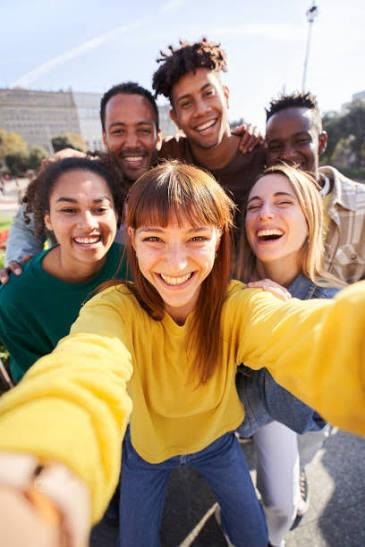

Processing image: /Users/sunnyraj/Downloads/images-10.jpeg
[2026-07-23 22:09:09] [INFO] [fashion_detector:utils.py:119] - Loading image from local path: /Users/sunnyraj/Downloads/images-10.jpeg



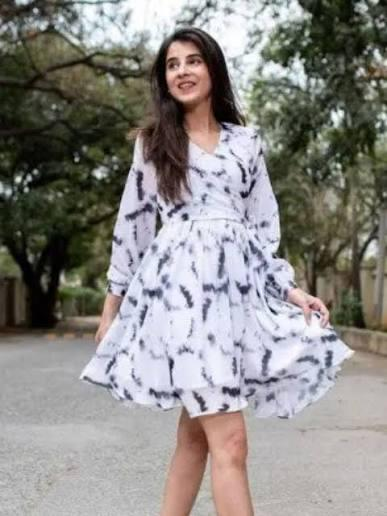

Processing image: /Users/sunnyraj/Downloads/images-11.jpeg
[2026-07-23 22:09:09] [INFO] [fashion_detector:utils.py:119] - Loading image from local path: /Users/sunnyraj/Downloads/images-11.jpeg



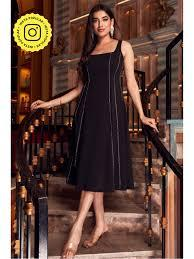

Processing image: /Users/sunnyraj/Downloads/images.jpeg
[2026-07-23 22:09:09] [INFO] [fashion_detector:utils.py:119] - Loading image from local path: /Users/sunnyraj/Downloads/images.jpeg



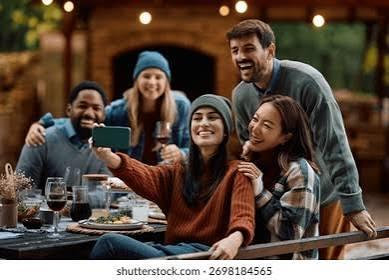

Processing image: /Users/sunnyraj/Downloads/images-2.jpeg
[2026-07-23 22:09:09] [INFO] [fashion_detector:utils.py:119] - Loading image from local path: /Users/sunnyraj/Downloads/images-2.jpeg



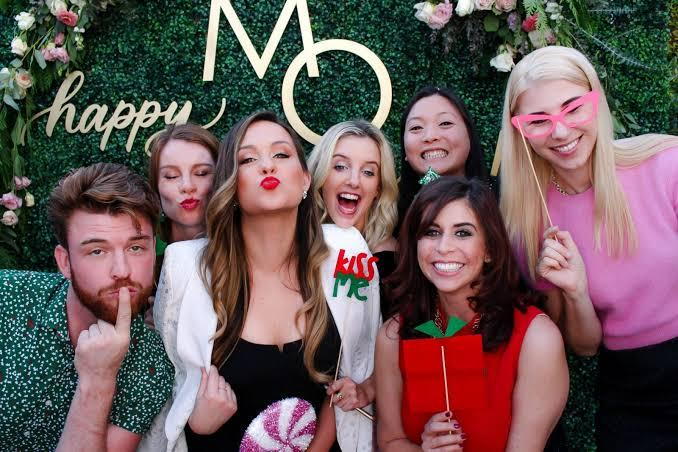

Processing image: /Users/sunnyraj/Downloads/images-5.jpeg
[2026-07-23 22:09:09] [INFO] [fashion_detector:utils.py:119] - Loading image from local path: /Users/sunnyraj/Downloads/images-5.jpeg



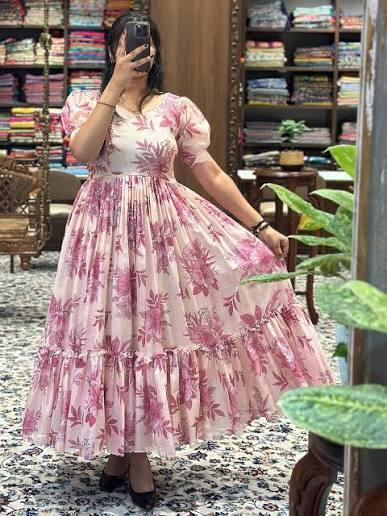

Processing image: /Users/sunnyraj/Downloads/images-16.jpeg
[2026-07-23 22:09:09] [INFO] [fashion_detector:utils.py:119] - Loading image from local path: /Users/sunnyraj/Downloads/images-16.jpeg



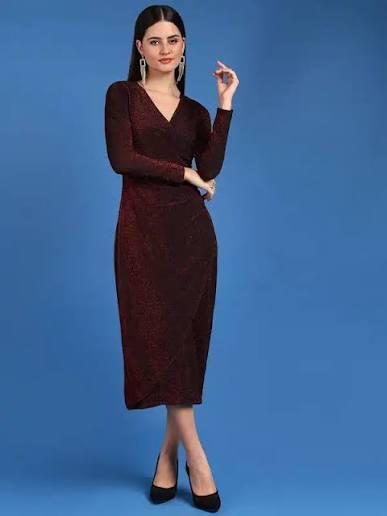

Processing image: /Users/sunnyraj/Downloads/images-9.jpeg
[2026-07-23 22:09:09] [INFO] [fashion_detector:utils.py:119] - Loading image from local path: /Users/sunnyraj/Downloads/images-9.jpeg



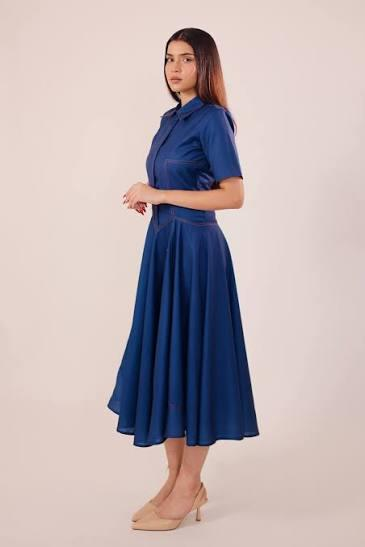

Processing image: /Users/sunnyraj/Downloads/images-8.jpeg
[2026-07-23 22:09:09] [INFO] [fashion_detector:utils.py:119] - Loading image from local path: /Users/sunnyraj/Downloads/images-8.jpeg



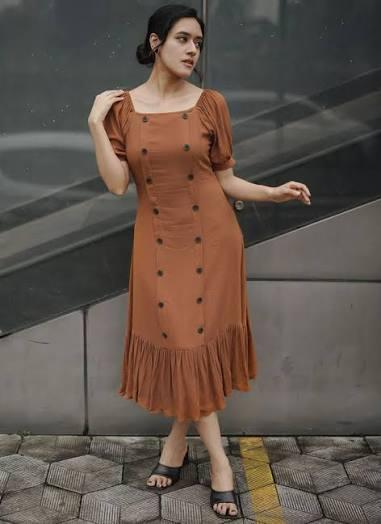

Processing image: /Users/sunnyraj/Downloads/images-17.jpeg
[2026-07-23 22:09:09] [INFO] [fashion_detector:utils.py:119] - Loading image from local path: /Users/sunnyraj/Downloads/images-17.jpeg



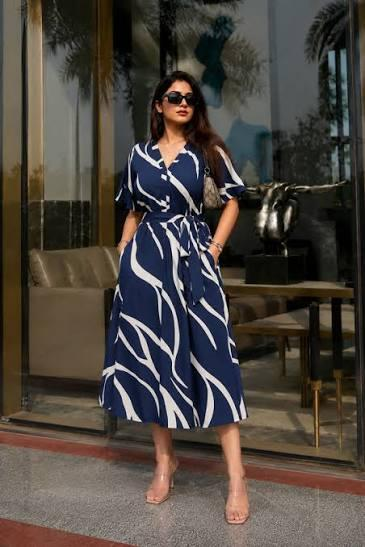

Processing image: /Users/sunnyraj/Downloads/images-4.jpeg
[2026-07-23 22:09:09] [INFO] [fashion_detector:utils.py:119] - Loading image from local path: /Users/sunnyraj/Downloads/images-4.jpeg



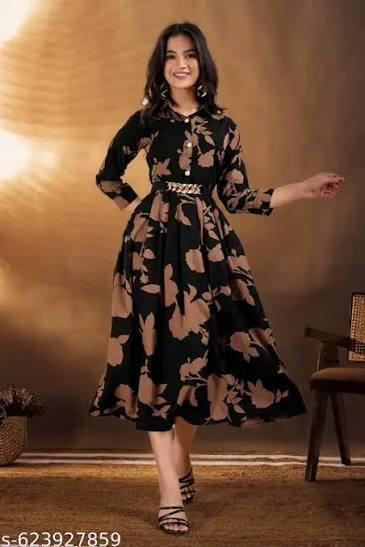

Processing image: /Users/sunnyraj/Downloads/images-14.jpeg
[2026-07-23 22:09:09] [INFO] [fashion_detector:utils.py:119] - Loading image from local path: /Users/sunnyraj/Downloads/images-14.jpeg



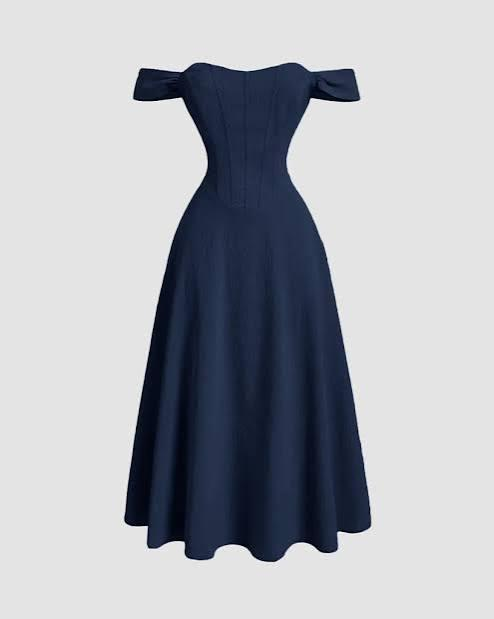

Processing image: /Users/sunnyraj/Downloads/images-7.jpeg
[2026-07-23 22:09:09] [INFO] [fashion_detector:utils.py:119] - Loading image from local path: /Users/sunnyraj/Downloads/images-7.jpeg



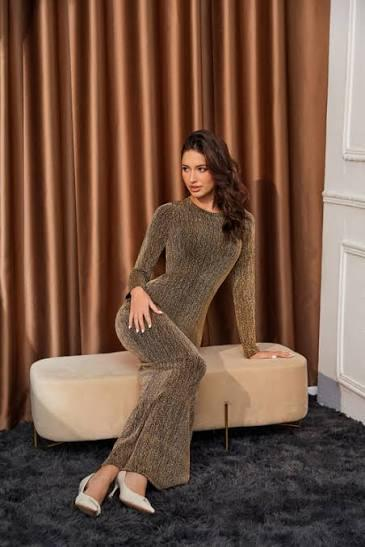

Processing image: /Users/sunnyraj/Downloads/images-6.jpeg
[2026-07-23 22:09:09] [INFO] [fashion_detector:utils.py:119] - Loading image from local path: /Users/sunnyraj/Downloads/images-6.jpeg



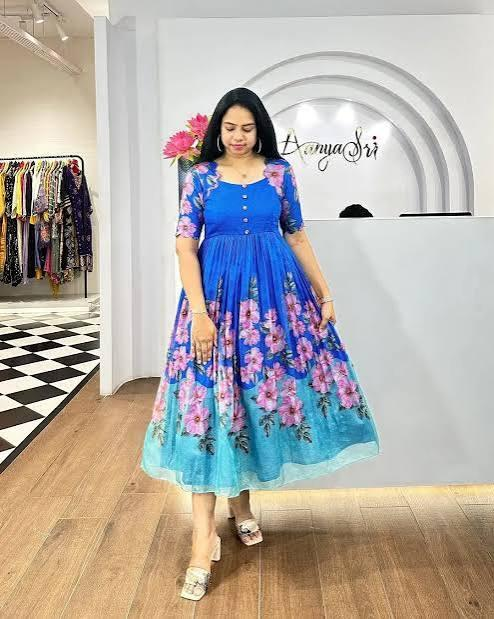

Processing image: /Users/sunnyraj/Downloads/images-15.jpeg
[2026-07-23 22:09:09] [INFO] [fashion_detector:utils.py:119] - Loading image from local path: /Users/sunnyraj/Downloads/images-15.jpeg



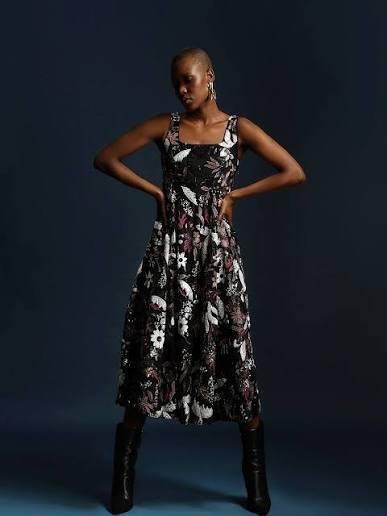

Processing image: /Users/sunnyraj/Downloads/images-12.jpeg
[2026-07-23 22:09:09] [INFO] [fashion_detector:utils.py:119] - Loading image from local path: /Users/sunnyraj/Downloads/images-12.jpeg



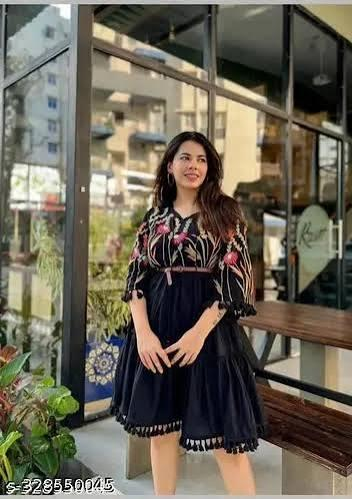

Processing image: /Users/sunnyraj/Downloads/images-13.jpeg
[2026-07-23 22:09:09] [INFO] [fashion_detector:utils.py:119] - Loading image from local path: /Users/sunnyraj/Downloads/images-13.jpeg



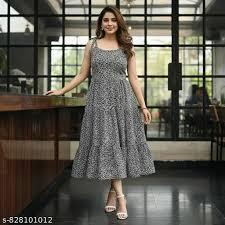

In [6]:
for det in detections:
    print(f"Processing image: {det['image_path']}")
    image = load_image(det['image_path'])
    box_inputs = det['detections']
    visualize_detections(image, box_inputs)